## Hệ Thống Phát Hiện Văn Bản AI (OOD-Robust AI Detection Pipeline)

Notebook này xây dựng một hệ thống phát hiện văn bản do AI tạo ra với khả năng **thích ứng ngoại miền (OOD-Robust)**, tập trung vào tiếng Việt. Hệ thống được thiết kế để giải quyết sự khác biệt về phân phối dữ liệu giữa tập huấn luyện và thực tế.

### 1. Mục Tiêu Chính
*   Xây dựng Pipeline trích xuất đặc trưng đa tầng: Logic, Ngữ pháp, Ngữ nghĩa và Động lực học (Surprisal).
*   Huấn luyện mô hình **XGBoost** kết hợp kỹ thuật **Adversarial Validation** để gán trọng số cho dữ liệu huấn luyện giống với dữ liệu thực tế (OOD).
*   Tối ưu hóa ngưỡng phân loại (Threshold) dựa trên F2-Score để ưu tiên khả năng bắt được AI (Recall) trong khi vẫn giữ độ chính xác (Precision) trên 70%.

### 2. Các Nhóm Đặc Trưng (Features)
*   **Causal Surprisal (GPT-Neo):** Đo lường độ bất ngờ của từ ngữ dựa trên mô hình ngôn ngữ lớn.
*   **Advanced Logic:** Sử dụng N-gram và Regex để phân tích mật độ các từ nối logic (Causal, Contrast, Additive, Temporal).
*   **Semantic Drift (PhoBERT):** Phân tích sự mạch lạc và độ trôi dạt ngữ nghĩa giữa các câu bằng Sentence Embeddings.
*   **Syntactic & Structural:** Các chỉ số về độ biến thiên độ dài câu, mật độ dấu câu và đại từ.

### 3. Quy Trình Kỹ Thuật
1.  **Adversarial Weighting:** Tính toán mức độ khác biệt giữa tập ID (Trong miền) và OOD (Ngoài miền) để điều chỉnh mô hình.
2.  **Calibration:** Hiệu chuẩn xác suất đầu ra (Sigmoid/Isotonic) để phản ánh đúng độ tin cậy.
3.  **Bootstrapping Threshold:** Quét tìm ngưỡng tối ưu ổn định qua nhiều vòng xáo trộn dữ liệu.

### 4. Sản Phẩm Đầu Ra (Artifacts)
*   `xgb_robust_final.joblib`: File model đã huấn luyện.
*   `model_config.json`: Chứa danh sách features và ngưỡng threshold tối ưu.
*   `logic_markers_prod.json`: Danh sách các N-gram logic đã học được từ quá trình EDA.
*   **Hugging Face Hub:** Tự động đẩy các artifacts lên repo để phục vụ triển khai (Streamlit/API).

In [ ]:
!pip install numpy pandas scikit-learn huggingface_hub xgboost transformers scipy torch shap betacal underthesea tqdm joblib ipython dotenv -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.7 MB/s eta 0:00:00


In [ ]:
import gc
import json
import os
import re
import string
import unicodedata
import warnings
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import torch
import xgboost as xgb
from huggingface_hub import login
from dotenv import find_dotenv, load_dotenv
from IPython.display import display
from scipy.stats import entropy
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GroupKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from tqdm import tqdm
from transformers import (
    AutoModel,
    AutoModelForCausalLM,
    AutoTokenizer,
)
from transformers import logging as transformers_logging
from underthesea import ner, pos_tag, sent_tokenize, word_tokenize
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
transformers_logging.set_verbosity_error()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
root_path = "/content/drive/MyDrive/BTL_AI_13_IT2302/AIWritingIndicator-13/SourceCode/"
%cd {root_path}
!pwd

/content/drive/.shortcut-targets-by-id/17JBaRqvfDFY0j8cN0vwu8kzqwtDISdDR/BTL_AI_13_IT2302/AIWritingIndicator-13/SourceCode
/content/drive/.shortcut-targets-by-id/17JBaRqvfDFY0j8cN0vwu8kzqwtDISdDR/BTL_AI_13_IT2302/AIWritingIndicator-13/SourceCode


In [ ]:
env_path = find_dotenv()

if env_path:
    load_dotenv(env_path)
else:
    print("Không tìm thấy file .env!")

In [ ]:
hf_token = os.getenv("HF_TOKEN")

if hf_token:
    login()
else:
    print("Không tồn tại env HF_TOKEN!")

In [ ]:
class OODRobustAIDetectionPipeline:
    def __init__(self, train_path, ood_path, artifact_dir="Model_Artifacts"):
        self.train_path = train_path
        self.ood_path = ood_path
        self.artifact_dir = artifact_dir

        os.makedirs(self.artifact_dir, exist_ok=True)

        self.features = []
        self.model = None
        self.optimal_threshold_ood = 0.5
        self.weights = None

        self.X_train_core = self.y_train_core = None
        self.X_id_test = self.y_id_test = None
        self.X_ood_val = self.y_ood_val = None
        self.X_ood_test = self.y_ood_test = None

    def load_and_prepare_data(self):
        print("1. Đang tải và chuẩn bị dữ liệu...")
        df_train = pd.read_csv(self.train_path)
        df_ood = pd.read_csv(self.ood_path)

        exclude_cols = ['label', 'text', 'id', 'origin', 'domain']
        self.features = [c for c in df_train.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(df_train[c])]

        print(f" -> Đã nhận diện {len(self.features)} numeric features.")

        self.X_train_core, self.X_id_test, self.y_train_core, self.y_id_test = train_test_split(
            df_train[self.features], df_train['label'],
            test_size=0.2, random_state=42, stratify=df_train['label']
        )

        self.X_ood_val, self.X_ood_test, self.y_ood_val, self.y_ood_test = train_test_split(
            df_ood[self.features], df_ood['label'],
            test_size=0.5, random_state=42, stratify=df_ood['label']
        )

    def calculate_sample_weights(self):
        print("2. Đang tính toán Importance Weights (Adversarial Validation)...")
        X_adv = pd.concat([self.X_train_core, self.X_ood_val], ignore_index=True)
        y_adv = np.array([0] * len(self.X_train_core) + [1] * len(self.X_ood_val))

        clf_adv_base = xgb.XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, n_jobs=-1)

        clf_adv = CalibratedClassifierCV(estimator=clf_adv_base, method='sigmoid', cv=5)
        clf_adv.fit(X_adv, y_adv)

        probs_adv_all = clf_adv.predict_proba(X_adv)[:, 1]
        auc_adv = roc_auc_score(y_adv, probs_adv_all)
        print(f" -> Adversarial AUC (Drift Score): {auc_adv:.4f}")

        if auc_adv <= 0.55:
            print(" -> [THÔNG BÁO] Phân phối ID và OOD gần như đồng nhất (AUC ~ 0.5). Gán uniform weights = 1.0.")
            self.weights = np.ones(len(self.X_train_core))
        else:
            p_ood = clf_adv.predict_proba(self.X_train_core)[:, 1]
            p_ood = np.clip(p_ood, 1e-5, 1 - 1e-5)

            logits = np.log(p_ood / (1 - p_ood))
            w_raw = np.exp(logits)

            lower_bound, upper_bound = 0.2, 3.0
            mid_point = (lower_bound + upper_bound) / 2.0

            self.weights = lower_bound + (upper_bound - lower_bound) * (1 / (1 + np.exp(-(w_raw - mid_point))))

        print(f" -> Mean weight cuối: {self.weights.mean():.3f}, Min: {self.weights.min():.3f}, Max: {self.weights.max():.3f}")

        plt.figure(figsize=(8, 5))
        plt.hist(self.weights, bins=50, color='teal', edgecolor='black', alpha=0.7)
        plt.title("Phân bố Adversarial Weights (Soft Clipped)")
        plt.xlabel("Weight Value")
        plt.ylabel("Frequency")
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()

    def _optimize_threshold(self, y_true, y_probs):
        print("\n--- THRESHOLD SCANNING LOG (OOD Thực tế) ---")

        brier = brier_score_loss(y_true, y_probs)
        print(f" -> Brier Score của Probabilities: {brier:.4f}")
        print("--------------------------------------------------")

        test_mocs = np.arange(0.02, 0.51, 0.02)
        for t in test_mocs:
            preds = (y_probs >= t).astype(int)
            rec = recall_score(y_true, preds, zero_division=0)
            prec = precision_score(y_true, preds, zero_division=0)
            f1 = f1_score(y_true, preds, zero_division=0)
            f2 = fbeta_score(y_true, preds, beta=2, zero_division=0)
            print(f" * Threshold = {t:.2f} | Recall = {rec:.4f} | Precision = {prec:.4f} | F1 = {f1:.4f} | F2 = {f2:.4f}")

        print("--------------------------------------------------")

        n_bootstraps = 50
        optimal_thresholds = []
        thresholds = np.arange(0.02, 0.51, 0.02)

        print(f" -> Đang chạy Bootstrapping ({n_bootstraps} vòng) để tìm ngưỡng Tối ưu (F2 cao nhất & Precision >= 0.7)...")

        for i in range(n_bootstraps):
            indices = np.random.choice(len(y_true), size=len(y_true), replace=True)

            if isinstance(y_true, (pd.Series, pd.DataFrame)):
                y_true_boot = y_true.iloc[indices].values
            else:
                y_true_boot = y_true[indices]

            y_probs_boot = y_probs[indices]

            best_f2 = 0
            best_t = 0.5

            for t in thresholds:
                preds = (y_probs_boot >= t).astype(int)
                prec = precision_score(y_true_boot, preds, zero_division=0)
                f2 = fbeta_score(y_true_boot, preds, beta=2, zero_division=0)

                if prec >= 0.7 and f2 > best_f2:
                    best_f2, best_t = f2, t

            if best_f2 == 0:
                for t in thresholds:
                    preds = (y_probs_boot >= t).astype(int)
                    f2 = fbeta_score(y_true_boot, preds, beta=2, zero_division=0)
                    if f2 > best_f2:
                        best_f2, best_t = f2, t

            optimal_thresholds.append(best_t)

        final_threshold = np.median(optimal_thresholds)

        final_preds = (y_probs >= final_threshold).astype(int)
        f_rec = recall_score(y_true, final_preds, zero_division=0)
        f_prec = precision_score(y_true, final_preds, zero_division=0)
        f_f1 = f1_score(y_true, final_preds, zero_division=0)
        f_f2 = fbeta_score(y_true, final_preds, beta=2, zero_division=0)

        print(f" -> Ngưỡng (Threshold) Tối ưu Median: {final_threshold:.2f}")
        print(f" -> Hiệu năng tại ngưỡng {final_threshold:.2f}:")
        print(f"    * Recall    : {f_rec:.4f}")
        print(f"    * Precision : {f_prec:.4f} (Mục tiêu >= 0.7)")
        print(f"    * F1-Score  : {f_f1:.4f}")
        print(f"    * F2-Score  : {f_f2:.4f} (Thang đo tối ưu chính)")

        if f_prec < 0.7:
             print("    [CẢNH BÁO] Hệ thống không tìm được ngưỡng nào thỏa mãn Precision >= 0.7, đã tự động Fallback về ngưỡng tối ưu F2 tốt nhất có thể.")

        return final_threshold

    def _calculate_ece(self, y_true, y_prob, n_bins=10):
        bin_limits = np.linspace(0, 1, n_bins + 1)
        bin_lowers = bin_limits[:-1]
        bin_uppers = bin_limits[1:]

        ece = 0.0
        for lower, upper in zip(bin_lowers, bin_uppers):
            in_bin = (y_prob > lower) & (y_prob <= upper)
            if lower == 0.0:
                in_bin = (y_prob >= lower) & (y_prob <= upper)

            prop_in_bin = in_bin.mean()
            if prop_in_bin > 0:
                accuracy_in_bin = y_true[in_bin].mean()
                avg_confidence_in_bin = y_prob[in_bin].mean()
                ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
        return ece

    def _select_best_calibration(self, base_model, iso_model, sig_model):
        probs_base = base_model.predict_proba(self.X_ood_val)[:, 1]
        probs_iso = iso_model.predict_proba(self.X_ood_val)[:, 1]
        probs_sig = sig_model.predict_proba(self.X_ood_val)[:, 1]

        brier_base = brier_score_loss(self.y_ood_val, probs_base)
        brier_iso = brier_score_loss(self.y_ood_val, probs_iso)
        brier_sig = brier_score_loss(self.y_ood_val, probs_sig)

        ece_base = self._calculate_ece(self.y_ood_val, probs_base)
        ece_iso = self._calculate_ece(self.y_ood_val, probs_iso)
        ece_sig = self._calculate_ece(self.y_ood_val, probs_sig)

        auc_base = roc_auc_score(self.y_ood_val, probs_base)
        auc_iso = roc_auc_score(self.y_ood_val, probs_iso)
        auc_sig = roc_auc_score(self.y_ood_val, probs_sig)

        print("\n--- CALIBRATION EVALUATION (OOD_Val) ---")
        print(f" * BASE     | Brier: {brier_base:.4f} | ECE: {ece_base:.4f} | AUC: {auc_base:.4f}")
        print(f" * SIGMOID  | Brier: {brier_sig:.4f}  | ECE: {ece_sig:.4f}  | AUC: {auc_sig:.4f}")
        print(f" * ISOTONIC | Brier: {brier_iso:.4f}  | ECE: {ece_iso:.4f}  | AUC: {auc_iso:.4f}")

        fig, ax = plt.subplots(figsize=(8, 8))
        CalibrationDisplay.from_predictions(self.y_ood_val, probs_base, n_bins=10, name="Base XGBoost", ax=ax, strategy='quantile')
        CalibrationDisplay.from_predictions(self.y_ood_val, probs_iso, n_bins=10, name="Isotonic", ax=ax, strategy='quantile')
        CalibrationDisplay.from_predictions(self.y_ood_val, probs_sig, n_bins=10, name="Sigmoid (Platt)", ax=ax, strategy='quantile')
        ax.set_title("Reliability Curve (OOD Validation)")
        ax.grid(True, linestyle='--', alpha=0.7)
        plt.show()

        best_ece = min(ece_base, ece_iso, ece_sig)
        tolerance_ece = ece_base * 0.05

        if (ece_base - best_ece) <= tolerance_ece:
            print(" -> [QUYẾT ĐỊNH] ECE không cải thiện quá 5%. CHỌN BASE XGBOOST (Bảo toàn model gốc).")
            return base_model

        if best_ece == ece_iso:
            if (auc_base - auc_iso) > 0.005:
                print(" -> [CẢNH BÁO ĐỎ] Isotonic có ECE tốt nhưng làm sụt giảm ROC-AUC > 0.005 (Phá hỏng Ranking).")
                print(" -> [QUYẾT ĐỊNH] Fallback về SIGMOID để giữ an toàn.")
                return sig_model
            else:
                print(" -> [QUYẾT ĐỊNH] Isotonic cải thiện ECE vượt trội và an toàn về AUC. CHỌN ISOTONIC.")
                return iso_model

        print(" -> [QUYẾT ĐỊNH] Sigmoid là phương án cân bằng nhất. CHỌN SIGMOID.")
        return sig_model

    def train_and_calibrate(self):
        print("\n3. Đang huấn luyện XGBoost OOD-Robust...")

        xgb_params = {
            'objective': 'binary:logistic',
            'eval_metric': 'logloss',
            'learning_rate': 0.03,
            'n_estimators': 700,
            'max_depth': 5,
            'min_child_weight': 3,
            'gamma': 2.0,
            'reg_alpha': 2.0,
            'reg_lambda': 5.0,
            'subsample': 0.8,
            'colsample_bytree': 0.6,
            'colsample_bynode': 0.6,
            'max_delta_step': 1,
            'tree_method': 'hist',
            'random_state': 42,
            'n_jobs': -1
        }

        print(" -> [FEATURE SELECTION] Đang chạy pre-training để đo tầm quan trọng của features...")
        pre_model = xgb.XGBClassifier(**xgb_params)
        pre_model.fit(self.X_train_core, self.y_train_core, sample_weight=self.weights)

        print(" -> [FEATURE SELECTION] Tính toán Permutation Importance...")
        perm_result = permutation_importance(
            pre_model, self.X_id_test, self.y_id_test,
            scoring='roc_auc', n_repeats=5, random_state=42, n_jobs=-1
        )

        selected_features = []
        threshold = np.percentile(perm_result.importances_mean, 25)
        for i, f in enumerate(self.features):
            if perm_result.importances_mean[i] > threshold:
                selected_features.append(f)

        if len(selected_features) == 0:
            print(" -> [CẢNH BÁO] Không có feature nào vượt ngưỡng importance. Giữ lại toàn bộ để fallback.")
            selected_features = self.features

        print(f" -> [FEATURE SELECTION] Đã giữ lại {len(selected_features)}/{len(self.features)} features thực sự mạnh (Importance > {threshold:.4f}).")

        self.features = selected_features

        print(" -> [FEATURE SELECTION] Đang kiểm tra tương quan giữa các features...")
        corr_matrix = self.X_train_core[self.features].corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

        to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

        if len(to_drop) > 0:
            self.features = [f for f in self.features if f not in to_drop]
            print(f" -> [FEATURE SELECTION] Đã loại bỏ {len(to_drop)} features do tương quan quá cao (>0.9). Còn lại {len(self.features)} features.")

        self.X_train_core = self.X_train_core[self.features]
        self.X_id_test = self.X_id_test[self.features]
        self.X_ood_val = self.X_ood_val[self.features]
        self.X_ood_test = self.X_ood_test[self.features]

        print(" -> Đang huấn luyện mô hình chính thức với các features đã chọn...")
        base_model = xgb.XGBClassifier(**xgb_params)
        base_model.fit(self.X_train_core, self.y_train_core, sample_weight=self.weights)

        iso_model = CalibratedClassifierCV(estimator=base_model, method='isotonic', cv='prefit')
        iso_model.fit(self.X_train_core, self.y_train_core)

        sig_model = CalibratedClassifierCV(estimator=base_model, method='sigmoid', cv='prefit')
        sig_model.fit(self.X_train_core, self.y_train_core)

        self.model = self._select_best_calibration(base_model, iso_model, sig_model)

        print("\n4. Đang tối ưu Threshold trên OOD Validation...")
        probs_ood_val = self.model.predict_proba(self.X_ood_val)[:, 1]
        self.optimal_threshold_ood = self._optimize_threshold(self.y_ood_val, probs_ood_val)
        print(f" -> Threshold Chốt Cuối Cùng: {self.optimal_threshold_ood:.3f}")

        self.plot_decision_curves(self.X_ood_val, self.y_ood_val, "OOD_Validation")

    def plot_decision_curves(self, X, y, dataset_name):
        probs = self.model.predict_proba(X)[:, 1]
        precisions, recalls, thresholds = precision_recall_curve(y, probs)

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        axes[0].plot(recalls, precisions, color='purple', lw=2)
        axes[0].set_xlabel("Recall (AI Detection Rate)")
        axes[0].set_ylabel("Precision")
        axes[0].set_title(f"Precision-Recall Curve ({dataset_name})")
        axes[0].grid(True, linestyle='--', alpha=0.6)

        axes[1].plot(thresholds, precisions[:-1], 'b--', label='Precision', lw=2)
        axes[1].plot(thresholds, recalls[:-1], 'g-', label='Recall', lw=2)
        axes[1].axvline(x=self.optimal_threshold_ood, color='red', linestyle='-', lw=2, label=f'Chosen Thresh ({self.optimal_threshold_ood:.2f})')
        axes[1].set_xlabel("Decision Threshold")
        axes[1].set_ylabel("Score")
        axes[1].set_title(f"Threshold Trade-off ({dataset_name})")
        axes[1].legend(loc="lower left")
        axes[1].grid(True, linestyle='--', alpha=0.6)

        plt.tight_layout()
        plt.show()

    def evaluate_model(self, X, y, dataset_name=""):
        print(f"\n--- ĐÁNH GIÁ TRÊN TẬP: {dataset_name} ---")
        probs = self.model.predict_proba(X)[:, 1]
        preds = (probs >= self.optimal_threshold_ood).astype(int)

        auc = roc_auc_score(y, probs)
        f1 = f1_score(y, preds)
        prec = precision_score(y, preds)
        rec = recall_score(y, preds)

        print(f"AUC: {auc:.4f} | F1: {f1:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}")
        print(classification_report(y, preds))

        return {"AUC": auc, "F1": f1, "Precision": prec, "Recall": rec}

    def run_sanity_checks(self):
        print("\n5. Đang chạy Sanity Checks (Trên tập OOD Test mù)...")
        result = permutation_importance(
            self.model, self.X_ood_test, self.y_ood_test,
            scoring='roc_auc', n_repeats=5, random_state=42, n_jobs=-1
        )

        importance_df = pd.DataFrame({
            'Feature': self.features,
            'Importance': result.importances_mean
        }).sort_values(by='Importance', ascending=False)

        top_f = importance_df.iloc[0]
        print(f"    * Feature mạnh nhất: {top_f['Feature']} (Drop AUC: {top_f['Importance']:.4f})")

        if top_f['Importance'] > 0.25:
            print("    [CẢNH BÁO ĐỎ] Mô hình có rủi ro Collapse (phụ thuộc quá mạnh vào 1 feature).")
        else:
            print("    [AN TOÀN] Không feature nào độc tôn. Mô hình học đặc trưng đa dạng.")

        return importance_df

    def save_artifacts(self, id_metrics, ood_metrics, importance_df):
        print("\n6. Đang lưu Artifacts...")
        joblib.dump(self.model, os.path.join(self.artifact_dir, "xgb_robust_final.joblib"))

        config = {
            "optimal_threshold_ood": float(self.optimal_threshold_ood),
            "features": self.features,
            "metrics_id": id_metrics,
            "metrics_ood": ood_metrics
        }
        with open(os.path.join(self.artifact_dir, "model_config.json"), "w", encoding="utf-8") as f:
            json.dump(config, f, indent=4)

        importance_df.to_csv(os.path.join(self.artifact_dir, "permutation_importance_ood.csv"), index=False)
        print(f" -> Hoàn tất! Artifacts được lưu tại: {self.artifact_dir}/")

    def execute_full_pipeline(self):
        print("=== BẮT ĐẦU PIPELINE XGBOOST OOD-ROBUST ===")
        self.load_and_prepare_data()
        self.calculate_sample_weights()
        self.train_and_calibrate()

        id_metrics = self.evaluate_model(self.X_id_test, self.y_id_test, "IN-DISTRIBUTION TEST (ID)")
        ood_metrics = self.evaluate_model(self.X_ood_test, self.y_ood_test, "OUT-OF-DISTRIBUTION TEST (OOD Mù)")

        importance_df = self.run_sanity_checks()
        self.save_artifacts(id_metrics, ood_metrics, importance_df)

In [ ]:
class HuggingFaceModelPusher:
    def __init__(self, repo_id, artifact_dir="Model_Artifacts"):
        self.repo_id = repo_id
        self.artifact_dir = artifact_dir
        self.api = HfApi()

    def push_to_hub(self, commit_message="Upload XGBoost OOD-Robust model and artifacts"):
        print(f"\n7. Đang đẩy model và artifacts từ thư mục '{self.artifact_dir}' lên Hugging Face Hub ({self.repo_id})...")

        self.api.create_repo(repo_id=self.repo_id, exist_ok=True, repo_type="model")

        self.api.upload_folder(
            folder_path=self.artifact_dir,
            repo_id=self.repo_id,
            repo_type="model",
            commit_message=commit_message
        )

        print(f" -> Hoàn tất đẩy dữ liệu lên Hugging Face! Bạn có thể xem tại: https://huggingface.co/{self.repo_id}")

=== BẮT ĐẦU PIPELINE XGBOOST OOD-ROBUST ===
1. Đang tải và chuẩn bị dữ liệu...
 -> Đã nhận diện 29 numeric features.
2. Đang tính toán Importance Weights (Adversarial Validation)...
 -> Adversarial AUC (Drift Score): 0.9523
 -> Mean weight cuối: 0.743, Min: 0.682, Max: 3.000


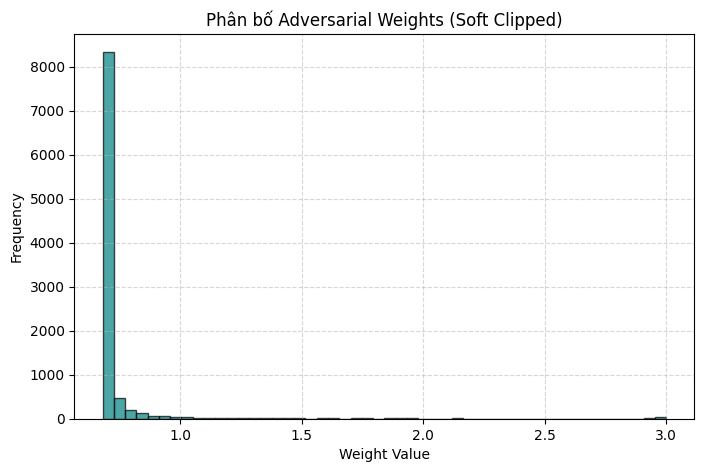


3. Đang huấn luyện XGBoost OOD-Robust...
 -> [FEATURE SELECTION] Đang chạy pre-training để đo tầm quan trọng của features...
 -> [FEATURE SELECTION] Tính toán Permutation Importance...
 -> [FEATURE SELECTION] Đã giữ lại 21/29 features thực sự mạnh (Importance > 0.0001).
 -> [FEATURE SELECTION] Đang kiểm tra tương quan giữa các features...
 -> [FEATURE SELECTION] Đã loại bỏ 2 features do tương quan quá cao (>0.9). Còn lại 19 features.
 -> Đang huấn luyện mô hình chính thức với các features đã chọn...

--- CALIBRATION EVALUATION (OOD_Val) ---
 * BASE     | Brier: 0.2161 | ECE: 0.2026 | AUC: 0.8467
 * SIGMOID  | Brier: 0.2450  | ECE: 0.2345  | AUC: 0.8467
 * ISOTONIC | Brier: 0.2331  | ECE: 0.2169  | AUC: 0.8451


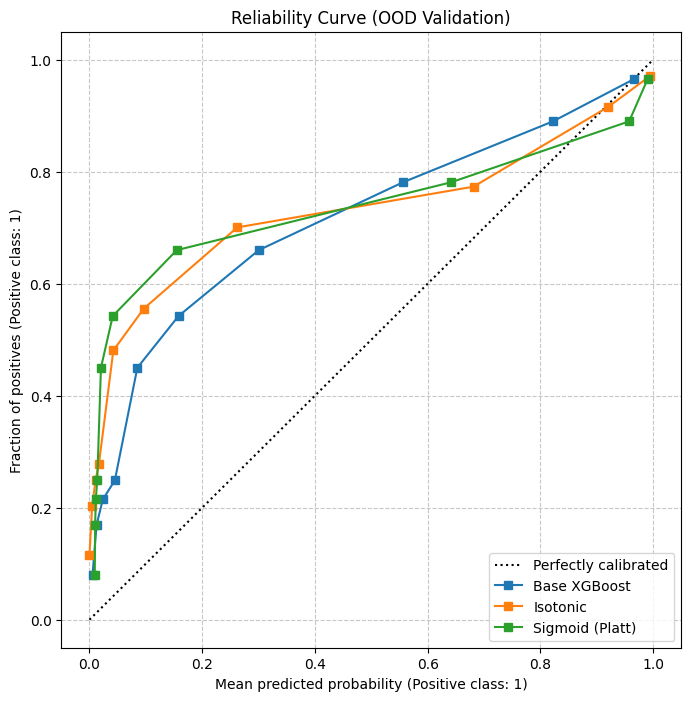

 -> [QUYẾT ĐỊNH] ECE không cải thiện quá 5%. CHỌN BASE XGBOOST (Bảo toàn model gốc).

4. Đang tối ưu Threshold trên OOD Validation...

--- THRESHOLD SCANNING LOG (OOD Thực tế) ---
 -> Brier Score của Probabilities: 0.2161
--------------------------------------------------
 * Threshold = 0.02 | Recall = 0.9402 | Precision = 0.6072 | F1 = 0.7379 | F2 = 0.8473
 * Threshold = 0.04 | Recall = 0.8893 | Precision = 0.6682 | F1 = 0.7630 | F2 = 0.8341
 * Threshold = 0.06 | Recall = 0.8604 | Precision = 0.7120 | F1 = 0.7792 | F2 = 0.8260
 * Threshold = 0.08 | Recall = 0.8195 | Precision = 0.7399 | F1 = 0.7777 | F2 = 0.8023
 * Threshold = 0.10 | Recall = 0.7896 | Precision = 0.7550 | F1 = 0.7719 | F2 = 0.7825
 * Threshold = 0.12 | Recall = 0.7597 | Precision = 0.7720 | F1 = 0.7658 | F2 = 0.7622
 * Threshold = 0.14 | Recall = 0.7348 | Precision = 0.7832 | F1 = 0.7582 | F2 = 0.7440
 * Threshold = 0.16 | Recall = 0.7089 | Precision = 0.7882 | F1 = 0.7465 | F2 = 0.7234
 * Threshold = 0.18 | Recall = 

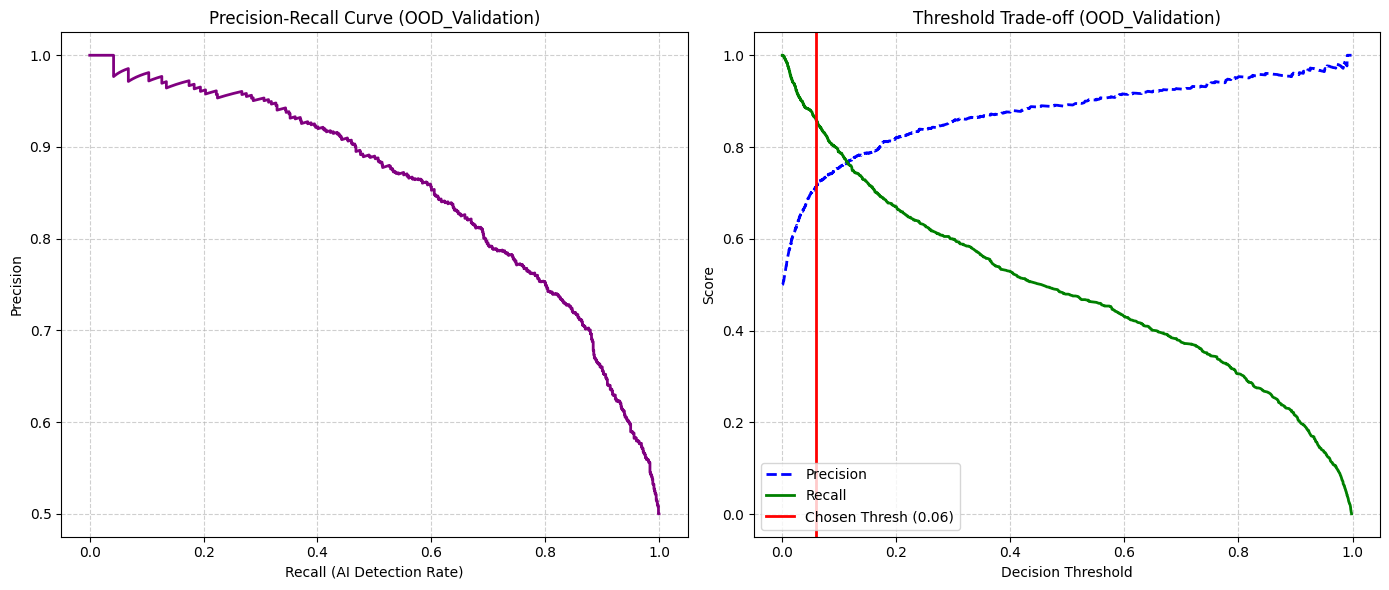


--- ĐÁNH GIÁ TRÊN TẬP: IN-DISTRIBUTION TEST (ID) ---
AUC: 0.9891 | F1: 0.8812 | Precision: 0.7907 | Recall: 0.9950
              precision    recall  f1-score   support

           0       0.99      0.74      0.85      1211
           1       0.79      1.00      0.88      1211

    accuracy                           0.87      2422
   macro avg       0.89      0.87      0.86      2422
weighted avg       0.89      0.87      0.86      2422


--- ĐÁNH GIÁ TRÊN TẬP: OUT-OF-DISTRIBUTION TEST (OOD Mù) ---
AUC: 0.8424 | F1: 0.7698 | Precision: 0.6965 | Recall: 0.8604
              precision    recall  f1-score   support

           0       0.82      0.63      0.71      1003
           1       0.70      0.86      0.77      1003

    accuracy                           0.74      2006
   macro avg       0.76      0.74      0.74      2006
weighted avg       0.76      0.74      0.74      2006


5. Đang chạy Sanity Checks (Trên tập OOD Test mù)...
    * Feature mạnh nhất: punctuation_density (Drop A

In [ ]:
pipeline = OODRobustAIDetectionPipeline(
    train_path="Data/Final/iccies_dataset_feature_integration_cleaned.csv",
    ood_path="Data/Final/vietnamese_news_ai_dataset_feature_integration_cleaned.csv",
    artifact_dir="Artifacts"
)
pipeline.execute_full_pipeline()

In [ ]:
hf_pusher = HuggingFaceModelPusher(
    repo_id="juniorthanh/xgboost_final_streamlit",
    artifact_dir="Artifacts"
)

hf_pusher.push_to_hub(commit_message="Upload XGBoost OOD-Robust model and calibration artifacts")

In [ ]:
def load_const_seeds(filepath="Data/const_seeds.json"):
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Lỗi không tìm thấy file cấu hình tại '{filepath}'.")

    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            return json.load(f)
    except json.JSONDecodeError as e:
        raise ValueError(f"File '{filepath}' không chuẩn định dạng JSON. Chi tiết lỗi: {e}")
    except Exception as e:
        raise RuntimeError(f"Lỗi không xác định khi đọc file '{filepath}': {e}")

CONST_SEED = load_const_seeds()

In [ ]:
class PipelineStep:
    def execute(self, df, text_col, label_col=None):
        raise NotImplementedError

In [ ]:
class CausalSurprisalStep(PipelineStep):
    def __init__(self, model_name="VietAI/gpt-neo-1.3B-vietnamese-news"):
        self.model_name = model_name
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.dtype = torch.float16 if torch.cuda.is_available() else torch.float32

    def safe(self, v):
        return 0.0 if np.isnan(v) or np.isinf(v) else float(v)

    def _aggregate_to_word_level(self, surprisal_array, word_ids):
        if len(surprisal_array) != len(word_ids):
            return surprisal_array
        word_surprisals = {}
        for surp, w_id in zip(surprisal_array, word_ids):
            if w_id is not None:
                word_surprisals[w_id] = word_surprisals.get(w_id, 0) + surp
        if not word_surprisals or len(surprisal_array) == 0 or len(word_ids) == 0:
            return np.array([])
        return np.array([word_surprisals[k] for k in sorted(word_surprisals.keys())])

    def execute(self, df, text_col, label_col=None):
        print("\n" + "="*60)
        print(" GIAI ĐOẠN 5A: CAUSAL SURPRISAL DYNAMICS (GPT-NEO) - PRODUCTION")
        print("="*60)

        feature_names = ['mean', 'var', 'tail', 'd2_entropy']
        metrics = {k: np.zeros(len(df)) for k in feature_names}

        print(f"[Causal LM] Đang tải lên VRAM: {self.model_name}...")
        try:
            tokenizer = AutoTokenizer.from_pretrained(self.model_name, use_fast=True)
            model = AutoModelForCausalLM.from_pretrained(self.model_name, torch_dtype=self.dtype)
            model.to(self.device)
            model.eval()
        except Exception as e:
            print(f"⚠️ Lỗi tải model {self.model_name}: {e}")
            return df

        loss_fct = torch.nn.CrossEntropyLoss(reduction='none')

        with torch.no_grad():
            for idx, text in enumerate(tqdm(df[text_col], desc="[GPT-Neo] Quét Causal")):
                try:
                    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=1024).to(self.device)
                    input_ids = inputs["input_ids"]

                    if input_ids.size(1) < 4:
                        continue

                    outputs = model(input_ids)
                    shift_logits = outputs.logits[..., :-1, :].contiguous()
                    shift_labels = input_ids[..., 1:].contiguous()

                    surprisal_tensor = loss_fct(shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1))
                    S_raw = surprisal_tensor.cpu().numpy().astype(np.float64)

                    word_ids = inputs.word_ids(batch_index=0)[1:]
                    S = self._aggregate_to_word_level(S_raw, word_ids)

                    if len(S) < 5 or np.std(S) < 1e-6:
                        continue

                    metrics['mean'][idx] = np.mean(S)
                    metrics['var'][idx] = np.var(S)
                    metrics['tail'][idx] = np.percentile(S, 95)

                    d1 = np.diff(S)
                    d2 = np.diff(d1)
                    if len(d2) > 10:
                        hist, _ = np.histogram(d2, bins=10, density=True)
                        metrics['d2_entropy'][idx] = entropy(hist + 1e-9)

                except Exception as e:
                    pass

        print(f"[Memory] Giải phóng VRAM của {self.model_name}...")
        del model, tokenizer
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        for k in feature_names:
            df[f'gpt_{k}'] = metrics[k]

        return df

In [ ]:
class AdvancedLogicFeatureExtractor(PipelineStep):
    def __init__(self,
                 seeds=None,
                 pronoun_list=None,
                 verb_noise_list=None,
                 ngram_range=(2, 6),
                 min_df=5,
                 max_df=0.7,
                 production_markers_path=None):

        self.groups = ['causal', 'contrast', 'additive', 'temporal']

        if not seeds:
          raise ValueError("Thiếu file seed")

        self.seeds = seeds

        self.pronoun_list = pronoun_list or {
            'tôi', 'ta', 'chúng ta', 'chúng tôi', 'mình', 'bạn', 'các bạn', 'họ', 'bọn họ', 'anh', 'chị', 'em', 'ông', 'bà', 'chú', 'bác', 'nó', 'hắn', 'tao', 'mày', 'tớ', 'tụi', 'tụi nó', 'bọn', 'bọn nó', 'anh ấy', 'chị ấy', 'cô ấy', 'ông ấy', 'bà ấy', 'anh ta', 'chị ta', 'họ ta', 'cô', 'dì', 'dượng', 'cậu', 'mợ', 'thầy', 'con', 'cháu', 'người ta', 'ai đó', 'mọi người', 'chúng nó', 'tụi mình', 'bọn mình'
        }

        self.verb_noise_list = verb_noise_list or {
            'nghĩ', 'thấy', 'cho rằng', 'rằng', 'là', 'sẽ', 'đã', 'đang'
        }

        self.ngram_range = ngram_range
        self.min_df = min_df
        self.max_df = max_df

        self.dynamic_markers = {g: set() for g in self.groups}
        self.dynamic_blacklist = set()
        self.regex_patterns = {}

        self.production_markers_path = production_markers_path
        if self.production_markers_path:
            self._load_production_markers()
            self._compile_regex_from_seeds()

    def _is_noise(self, ngram):
        for p in self.pronoun_list:
            for v in self.verb_noise_list:
                if f"{p} {v}" in ngram:
                    return True

        if len(ngram.split()) > 6:
            return True

        return False

    def _build_dynamic_markers_in_memory(self, df, text_col):
        print("1. Đang cắt đầu câu (Sentence Starters)...")
        starters = []
        for text in df[text_col].dropna():
            sentences = sent_tokenize(str(text))
            for sent in sentences:
                words = sent.split()
                if len(words) >= 2:
                    starters.append(sent.lower())

        if not starters:
            print("⚠️ CẢNH BÁO: Dữ liệu trống. Sẽ sử dụng Seeds mặc định.")
            self._compile_regex_from_seeds()
            return

        print("2. Đang tạo N-gram và đếm tần suất...")
        vectorizer = CountVectorizer(ngram_range=self.ngram_range, min_df=self.min_df, max_df=self.max_df)
        X = vectorizer.fit_transform(starters)
        freqs = zip(vectorizer.get_feature_names_out(), X.sum(axis=0).tolist()[0])
        sorted_ngrams = sorted(freqs, key=lambda x: x[1], reverse=True)

        print("3. Khởi chạy Dynamic Noise Filter và phân loại (RAM)...")
        for ngram, freq in sorted_ngrams:
            if self._is_noise(ngram):
                self.dynamic_blacklist.add(ngram)
                continue

            for g, seed_words in self.seeds.items():
                if any(s in ngram for s in seed_words):
                    self.dynamic_markers[g].add(ngram)
                    break

        self._compile_regex_from_seeds()

        print(f"✅ Hoàn tất lưu pipeline N-gram vào bộ nhớ.")
        print(f"⚠️ Đã lọc tự động {len(self.dynamic_blacklist)} cụm nhiễu.")

    def _compile_regex_from_seeds(self):
        for g in self.groups:
            manual_seeds = set(self.seeds.get(g, []))
            dynamic_found = self.dynamic_markers[g]

            all_markers = manual_seeds.union(dynamic_found)

            if not all_markers:
                continue

            sorted_markers = sorted(list(all_markers), key=len, reverse=True)
            pattern = r'(?<!\w)(' + '|'.join(map(re.escape, sorted_markers)) + r')(?!\w)'
            self.regex_patterns[g] = re.compile(pattern, re.IGNORECASE | re.UNICODE)

    def _extract_logic_metrics(self, text):
        sentences = sent_tokenize(str(text))
        num_sentences = len(sentences)

        res = {f'{g}_count': 0 for g in self.groups}
        res['transition_count'] = 0

        if num_sentences == 0:
            return pd.Series(res)

        for i, sent in enumerate(sentences):
            sent_lower = sent.lower()
            is_transition = False

            for g in self.groups:
                if g not in self.regex_patterns:
                    continue

                pattern = self.regex_patterns[g]
                matches = list(pattern.finditer(sent_lower))
                count = len(matches)

                if count > 0:
                    res[f'{g}_count'] += count

                    if not is_transition and matches[0].start() <= 20:
                        is_transition = True

            if is_transition:
                res['transition_count'] += 1

        res['num_sentences'] = num_sentences
        return pd.Series(res)

    def export_markers_for_production(self, expected_logic_val, filepath="Data/logic_markers_prod.json"):
        export_data = {
            "markers": {k: list(v) for k, v in self.dynamic_markers.items()},
            "expected_logic": float(expected_logic_val)
        }
        with open(filepath, 'w', encoding='utf-8') as f:
            json.dump(export_data, f, ensure_ascii=False, indent=4)
        print(f"\n✅ Đã xuất cấu hình sang môi trường Production: {filepath}")

    def _load_production_markers(self):
        try:
            with open(self.production_markers_path, 'r', encoding='utf-8') as f:
                data = json.load(f)

            if "markers" in data:
                self.dynamic_markers = {k: set(v) for k, v in data["markers"].items()}
                self.saved_expected_logic = data.get("expected_logic", 0.0)
            else:
                self.dynamic_markers = {k: set(v) for k, v in data.items()}
                self.saved_expected_logic = 0.0

            print(f"✅ Đã nạp thành công N-gram & Mean từ EDA: {self.production_markers_path}")
        except Exception as e:
            print(f"❌ Lỗi nạp file N-gram Production: {e}")
            self.saved_expected_logic = 0.0

    def execute(self, df, text_col, label_col=None):
        print("\n" + "="*60)
        print(" PIPELINE: KHAI PHÁ N-GRAM & TRÍCH XUẤT ĐẶC TRƯNG LOGIC")
        print("="*60)

        if not self.production_markers_path:
            self._build_dynamic_markers_in_memory(df, text_col)

        if 'seg_length' not in df.columns:
            df['seg_length'] = df[text_col].apply(lambda x: len(str(x).split()))

        try:
            tqdm.pandas(desc="[Logic] Áp dụng Regex tính Metrics")
            metrics_df = df[text_col].progress_apply(self._extract_logic_metrics)
        except (AttributeError, NameError):
            metrics_df = df[text_col].apply(self._extract_logic_metrics)

        df = pd.concat([df, metrics_df], axis=1)

        for g in self.groups:
            df[f'{g}_density'] = df[f'{g}_count'] / (df['seg_length'] + 1e-6)

        df['logic_transition_points'] = df['transition_count'] / (df['num_sentences'] + 1e-6)

        densities = df[[f'{g}_density' for g in self.groups]]
        df['logic_mismatch_score'] = densities.std(axis=1)

        df['logic_density'] = sum(df[f'{g}_count'] for g in self.groups) / (df['seg_length'] + 1e-6)

        if self.production_markers_path:
            expected_logic = getattr(self, 'saved_expected_logic', 0.0)
        else:
            expected_logic = float(df['logic_density'].mean())
            self.export_markers_for_production(expected_logic, "Data/logic_markers_prod.json")

        df['logic_deviation'] = abs(df['logic_density'] - expected_logic)

        df = df.drop(columns=['logic_transition_points','num_sentences', 'transition_count'] + [f'{g}_count' for g in self.groups])

        return df

In [ ]:
class SyntacticAndStructuralStep(PipelineStep):
    def __init__(self):
        raw_pronouns = [
            "tôi", "tao", "tớ", "mình", "ta", "chúng tôi", "chúng ta", "tụi tôi", "bọn tôi", "tụi mình",
            "bạn", "cậu", "mày", "mi", "các bạn", "tụi bây", "bọn mày", "nó", "hắn", "y", "người ta",
            "họ", "chúng nó", "tụi nó", "bọn họ", "ai", "gì", "nào", "bao nhiêu", "bao giờ"
        ]
        self.pronoun_set = set([p.replace(" ", "_") for p in raw_pronouns])

    def _compute_recombined_features(self, text):
        paragraphs = [p for p in text.split('\n') if p.strip()]
        sentences = []
        for p in paragraphs: sentences.extend(sent_tokenize(p))

        sent_words = [word_tokenize(s) for s in sentences]
        sent_lengths = [len(words) for words in sent_words]
        total_words = sum(sent_lengths)
        total_words_safe = max(1, total_words)

        sent_len_mean = float(np.mean(sent_lengths)) if sent_lengths else 0.0
        sent_len_var = float(np.var(sent_lengths)) if sent_lengths else 0.0
        sent_len_cv = sent_len_var / (sent_len_mean + 1e-6)

        comma_counts = [s.count(',') for s in sentences]
        punct_counts = [sum(1 for char in s if char in string.punctuation) for s in sentences]

        comma_density = sum(comma_counts) / total_words_safe
        punctuation_density = sum(punct_counts) / total_words_safe

        all_words_lower = [w.lower() for words in sent_words for w in words]
        total_pronouns = sum(1 for w in all_words_lower if w in self.pronoun_set)
        pronoun_ratio = total_pronouns / total_words_safe

        return (sent_len_cv, comma_density, punctuation_density, pronoun_ratio)

    def execute(self, df, text_col, label_col=None):
        res = df[text_col].apply(self._compute_recombined_features)
        cols = ['sent_len_cv', 'comma_density', 'punctuation_density', 'pronoun_ratio']
        df[cols] = pd.DataFrame(res.tolist(), index=df.index)
        return df

In [ ]:
class PhoBERTFeaturePipeline(PipelineStep):
    def __init__(self, model_name="vinai/phobert-base-v2", batch_size=16):
        self.model_name = model_name
        self.batch_size = batch_size
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.max_length = 256
        self.stride = 128

    def _compute_cpu_features(self, text):
        if not isinstance(text, str) or not text.strip():
            return (0.0, 0.0, [])

        try:
            sentences = sent_tokenize(text)

            pos_var = 0.0
            try:
                tags = pos_tag(text)
                if tags:
                    pos_counts = Counter(tag for _, tag in tags)
                    total_tags = sum(pos_counts.values())
                    probs = [c / total_tags for c in pos_counts.values()]
                    pos_var = float(np.var(probs))
            except Exception:
                pass

            entity_grid = 0.0
            try:
                if len(sentences) > 1:
                    sentence_entities = []
                    for s in sentences:
                        entities = {w for w, _, _, tg in ner(s) if tg != 'O'}
                        entities.update(w for w, tg in pos_tag(s) if str(tg).startswith('N'))
                        sentence_entities.append(entities)

                    overlaps = [len(set1 & set2) / max(1, len(set1 | set2))
                                for set1, set2 in zip(sentence_entities[:-1], sentence_entities[1:])]
                    if overlaps:
                        entity_grid = float(np.mean(overlaps))
            except Exception:
                pass

            return (pos_var, entity_grid, sentences)

        except Exception:
            return (0.0, 0.0, [])

    def _mean_pooling(self, model_output, attention_mask):
        token_embeddings = model_output[0]
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

    def _get_sentence_embeddings(self, sentences, tokenizer, model):
        if not sentences: return np.array([])

        chunked_inputs = []
        sentence_to_chunk_map = []
        current_chunk_idx = 0

        tokenized_sents = tokenizer(sentences, add_special_tokens=False, return_attention_mask=False)['input_ids']

        for tokens in tokenized_sents:
            if len(tokens) <= self.max_length - 2:
                chunked_inputs.append([tokenizer.cls_token_id] + tokens + [tokenizer.sep_token_id])
                sentence_to_chunk_map.append([current_chunk_idx])
                current_chunk_idx += 1
            else:
                sent_chunks_idx = []
                for i in range(0, len(tokens), self.max_length - self.stride - 2):
                    window_tokens = tokens[i : i + (self.max_length - 2)]
                    chunked_inputs.append([tokenizer.cls_token_id] + window_tokens + [tokenizer.sep_token_id])
                    sent_chunks_idx.append(current_chunk_idx)
                    current_chunk_idx += 1
                sentence_to_chunk_map.append(sent_chunks_idx)

        chunk_embeddings = []
        model.eval()
        pad_id = tokenizer.pad_token_id

        with torch.no_grad():
            for i in range(0, len(chunked_inputs), self.batch_size):
                batch_tokens = chunked_inputs[i : i + self.batch_size]

                max_len = max(len(t) for t in batch_tokens)

                input_ids = torch.tensor(
                    [t + [pad_id] * (max_len - len(t)) for t in batch_tokens],
                    dtype=torch.long, device=self.device
                )
                attention_mask = (input_ids != pad_id).float()

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                embeddings = self._mean_pooling(outputs, attention_mask)
                embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)

                chunk_embeddings.append(embeddings.cpu().numpy())

        chunk_embeddings = np.concatenate(chunk_embeddings, axis=0)

        all_sentence_embeddings = np.empty((len(sentence_to_chunk_map), chunk_embeddings.shape[1]), dtype=np.float32)

        for idx, chunk_indices in enumerate(sentence_to_chunk_map):
            sent_embeds = chunk_embeddings[chunk_indices]
            final_sent_embed = np.mean(sent_embeds, axis=0)
            norm = np.linalg.norm(final_sent_embed)
            if norm > 0:
                final_sent_embed = final_sent_embed / norm
            all_sentence_embeddings[idx] = final_sent_embed

        return all_sentence_embeddings

    def execute(self, df, text_col, label_col=None, **kwargs):
        cpu_results = [self._compute_cpu_features(text) for text in df[text_col]]

        df['pos_distribution_variance'] = [x[0] for x in cpu_results]
        df['entity_grid_score'] = [x[1] for x in cpu_results]

        all_sentences = []
        text_sent_indices = []
        current_idx = 0

        for res in cpu_results:
            sents = res[2]
            n_sents = len(sents)
            text_sent_indices.append((current_idx, current_idx + n_sents))
            all_sentences.extend(sents)
            current_idx += n_sents

        if not all_sentences:
            for col in ['sentence_embedding_coherence', 'topic_drift_score', 'semantic_drift_score', 'embedding_distribution_entropy']:
                df[col] = 0.0
            return df

        tokenizer = None
        model = None
        try:
            tokenizer = AutoTokenizer.from_pretrained(self.model_name)
            model = AutoModel.from_pretrained(self.model_name).to(self.device)
            all_embeddings = self._get_sentence_embeddings(all_sentences, tokenizer, model)
        except Exception as e:
            print(f"Lỗi khởi tạo/chạy mô hình: {e}")
            for col in ['sentence_embedding_coherence', 'topic_drift_score', 'semantic_drift_score', 'embedding_distribution_entropy']:
                df[col] = 0.0
            return df
        finally:
            if model is not None:
                del model
            if tokenizer is not None:
                del tokenizer
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        n_docs = len(text_sent_indices)
        coherences = np.zeros(n_docs, dtype=np.float32)
        topic_drifts = np.zeros(n_docs, dtype=np.float32)
        sem_drifts = np.zeros(n_docs, dtype=np.float32)
        entropies = np.zeros(n_docs, dtype=np.float32)

        for doc_idx, (start, end) in enumerate(text_sent_indices):
            n = end - start
            if n < 2:
                continue

            doc_embeds = all_embeddings[start:end]

            sims = np.sum(doc_embeds[:-1] * doc_embeds[1:], axis=1)
            sims = np.clip(sims, -1.0, 1.0)

            coherences[doc_idx] = float(np.mean(sims))
            topic_drifts[doc_idx] = float(np.var(sims))

            sem_drift = 1.0 - np.clip(np.dot(doc_embeds[0], doc_embeds[-1]), -1.0, 1.0)
            sem_drifts[doc_idx] = float(sem_drift)

            try:
                centered_embeds = doc_embeds - np.mean(doc_embeds, axis=0)
                _, S, _ = np.linalg.svd(centered_embeds, full_matrices=False)
                explained_variance = (S ** 2) / (n - 1)
                total_var = np.sum(explained_variance)

                if total_var > 0:
                    probs = explained_variance / total_var
                    probs = probs[probs > 0]
                    entropies[doc_idx] = float(-np.sum(probs * np.log2(probs)))
            except np.linalg.LinAlgError:
                pass

        df['sentence_embedding_coherence'] = coherences
        df['topic_drift_score'] = topic_drifts
        df['semantic_drift_score'] = sem_drifts
        df['embedding_distribution_entropy'] = entropies

        return df

In [ ]:
class InteractionFeatureStep(PipelineStep):
    def execute(self, df: pd.DataFrame, text_col: str, label_col: str) -> pd.DataFrame:
        out_df = df.copy()

        out_df['gpt_var_x_semantic_drift'] = out_df['gpt_var'] * out_df['semantic_drift_score']
        out_df['gpt_mean_x_embedding_coherence'] = out_df['gpt_mean'] * out_df['sentence_embedding_coherence']
        out_df['gpt_tail_x_semantic_drift'] = out_df['gpt_tail'] * out_df['semantic_drift_score']

        out_df['comma_density_x_gpt_var'] = out_df['comma_density'] * out_df['gpt_var']

        out_df['logic_deviation_x_embedding_coherence'] = out_df['logic_deviation'] * out_df['sentence_embedding_coherence']

        out_df['transition_density'] = (out_df['causal_density'] +
                                        out_df['contrast_density'] +
                                        out_df['additive_density'] +
                                        out_df['temporal_density'])

        out_df['embedding_coherence_x_entropy'] = out_df['sentence_embedding_coherence'] * out_df['embedding_distribution_entropy']
        out_df['semantic_drift_x_entropy'] = out_df['semantic_drift_score'] * out_df['embedding_distribution_entropy']

        out_df['semantic_drift_ratio'] = out_df['semantic_drift_score'] / (out_df['gpt_var'] + 1e-5)

        out_df['combo_gpt_sent_punct'] = out_df['gpt_var'] * out_df['sent_len_cv'] * out_df['punctuation_density']

        print("Hoàn thành tính toán các đặc trưng tương tác.")
        return out_df

In [ ]:
class TextAnalyzerUI:
    def __init__(self, const_seeds):
        self.logic_extractor = AdvancedLogicFeatureExtractor(
            seeds=const_seeds,
            production_markers_path="Data/logic_markers_prod.json"
        )
        self.syntax_extractor = SyntacticAndStructuralStep()
        self.semantic_extractor = PhoBERTFeaturePipeline()
        self.causal_extractor = CausalSurprisalStep(
            model_name="VietAI/gpt-neo-1.3B-vietnamese-news"
        )

        self.interaction_extractor = InteractionFeatureStep()

        self.disallowed_pattern = re.compile(
            r'[^a-zA-Z0-9\s\.,\?!\-\(\)\'"“”‘’/_%àáãạảăắằẳẵặâấầẩẫậèéẹẻẽêềếểễệđìíĩỉịòóõọỏôốồổỗộơớờởỡợùúũụủưứừửữựỳýỹỷỵÀÁÃẠẢĂẮẰẲẴẶÂẤẦẨẪẬÈÉẸẺẼÊỀẾỂỄỆĐÌÍĨỈỊÒÓÕỌỎÔỐỒỔỖỘƠỚỜỞỠỢÙÚŨỤỦƯỨỪỬỮỰỲÝỸỶỴ]+'
        )

    def _validate_and_clean(self, text):
        if not isinstance(text, str):
            return False, "Dữ liệu đầu vào phải là văn bản (String)."

        text = unicodedata.normalize('NFC', text.strip())
        text = re.sub(r'[\r\n\t]+', ' ', text)

        text = re.sub(r'(http[s]?://|www\.|<.*?>|\S+@\S+|#\w+|@\w+)', '', text)
        text = text.replace(":", "")
        text = re.sub(self.disallowed_pattern, ' ', text)
        text = re.sub(r'\s{2,}', ' ', text)
        text = text.strip()

        if not text:
            return False, "Văn bản trống hoặc chỉ chứa ký tự rác."

        upper_chars = sum(1 for c in text if c.isupper())
        if len(text) > 0 and (upper_chars / len(text)) > 0.2:
            text = text.lower()

        if text[0].isalpha() and not text[0].isupper():
            text = text[0].upper() + text[1:]

        if not text.endswith('.'):
            last_period_index = text.rfind('.')
            if last_period_index == -1:
                return False, "Văn bản phải chứa ít nhất một dấu chấm câu kết thúc."
            text = text[:last_period_index + 1]

        if not text[0].isalpha():
            return False, f"Văn bản phải bắt đầu bằng chữ cái (Hiện tại: '{text[0]}')."

        if text.count('"') % 2 != 0:
            return False, "Lỗi cú pháp: Số lượng dấu ngoặc kép không đồng đều."

        words = text.split()
        word_count = len(words)

        if word_count < 200 or word_count > 2000:
            return False, f"Độ dài không hợp lệ ({word_count} từ). Yêu cầu từ 200 đến 2000 từ."

        vietnamese_vowels = re.findall(r'[àáãạảăắằẳẵặâấầẩẫậèéẹẻẽêềếểễệđìíĩỉịòóõọỏôốồổỗộơớờởỡợùúũụủưứừửữựỳýỹỷỵ]', text.lower())
        if (len(vietnamese_vowels) / word_count) < 0.2:
            return False, "Tỷ lệ nguyên âm tiếng Việt quá thấp (Nghi ngờ Spam)."

        return True, text

    def process_request(self, user_input_text):
        is_valid, result = self._validate_and_clean(user_input_text)

        if not is_valid:
            return {
                "status": "error",
                "message": result,
                "features": None
            }

        try:
            df = pd.DataFrame([{"text": result}])
            df = self.logic_extractor.execute(df, text_col='text')
            df = self.syntax_extractor.execute(df, text_col='text')
            df = self.semantic_extractor.execute(df, text_col='text')
            df = self.causal_extractor.execute(df, text_col='text')

            df = df.drop(columns=['text', 'seg_length'], errors='ignore')
            features_dict = df.iloc[0].to_dict()

            return {
                "status": "success",
                "message": "Trích xuất đặc trưng thành công.",
                "features": features_dict
            }
        except Exception as e:
            return {
                "status": "error",
                "message": f"Lỗi trích xuất: {str(e)}",
                "features": None
            }

    def execute(self, df, text_col='text'):
        validation_results = df[text_col].apply(self._validate_and_clean)

        df['is_valid'] = validation_results.apply(lambda x: x[0])
        df['processed_text'] = validation_results.apply(lambda x: x[1])
        df['error_msg'] = validation_results.apply(lambda x: x[1] if not x[0] else None)

        valid_df = df[df['is_valid']].copy()
        invalid_df = df[~df['is_valid']].copy()

        if not valid_df.empty:
            valid_df = self.logic_extractor.execute(valid_df, text_col='processed_text')
            valid_df = self.syntax_extractor.execute(valid_df, text_col='processed_text')
            valid_df = self.semantic_extractor.execute(valid_df, text_col='processed_text')
            valid_df = self.causal_extractor.execute(valid_df, text_col='processed_text')
            valid_df = self.interaction_extractor.execute(valid_df, text_col='processed_text', label_col=None)

        result_df = pd.concat([valid_df, invalid_df], ignore_index=False)
        result_df = result_df.sort_index()

        return result_df

In [ ]:
class BatchEvaluator:
    def __init__(self, text_analyzer, trained_model, model_config):
        self.analyzer = text_analyzer
        self.model = trained_model
        self.feature_names = model_config.get("features", [])
        self.threshold = model_config.get("optimal_threshold_ood")

        if not self.feature_names:
            print("CẢNH BÁO: Không tìm thấy danh sách 'features' trong config!")

    def evaluate_dataframe(self, df, text_col='text', label_col='label'):
        print(f"Bắt đầu đánh giá trên {len(df)} mẫu dữ liệu...\nNgưỡng: {self.threshold}")

        extracted_df = self.analyzer.execute(df.copy(), text_col=text_col)

        missing_cols = [col for col in self.feature_names if col not in extracted_df.columns]
        if missing_cols:
             print(f"LỖI NGHIÊM TRỌNG: Dữ liệu trích xuất thiếu các cột: {missing_cols}")
             return None

        valid_df = extracted_df[self.feature_names].fillna(0.0)

        if hasattr(self.model, "predict_proba"):
            raw_probs = self.model.predict_proba(valid_df)[:, 1]

            scaled_probs = np.where(
                raw_probs < self.threshold,
                (raw_probs / self.threshold) * 0.5,
                0.5 + ((raw_probs - self.threshold) / (1.0 - self.threshold)) * 0.5
            )

            probabilities = scaled_probs
            predictions = (scaled_probs >= 0.5).astype(int)

        else:
            probabilities = [None] * len(valid_df)
            predictions = self.model.predict(valid_df)

        extracted_df['predicted_label'] = predictions
        extracted_df['probability'] = probabilities

        if label_col in extracted_df.columns:
            extracted_df['is_correct'] = extracted_df['predicted_label'] == extracted_df[label_col]

        total_samples = len(df)
        valid_samples = len(extracted_df)

        print("\n" + "="*80)
        print(" BÁO CÁO KẾT QUẢ DỰ ĐOÁN TỔNG QUAN")
        print("="*80)
        print(f"Ngưỡng phân loại (Threshold) : {self.threshold:.4f}")
        print(f"Tổng số mẫu                : {total_samples}")
        print(f"Mẫu hợp lệ dự đoán thành công: {valid_samples}")

        if label_col in extracted_df.columns and valid_samples > 0:
            correct_predictions = extracted_df['is_correct'].sum()
            incorrect_predictions = valid_samples - correct_predictions
            accuracy = (correct_predictions / valid_samples * 100)
            print("-" * 80)
            print(f"Dự đoán ĐÚNG      : {correct_predictions}")
            print(f"Dự đoán SAI       : {incorrect_predictions}")
            print(f"Độ chính xác (Acc): {accuracy:.2f}%")

        print("\n" + "="*80)
        print(" DANH SÁCH CHI TIẾT CÁC MẪU DỮ LIỆU & ĐẶC TRƯNG")
        print("="*80)

        for index, row in extracted_df.iterrows():
            idx = index
            pred_lbl = row['predicted_label']
            prob = row['probability']
            snippet = str(row[text_col])[:70].replace('\n', ' ') + "..."

            if isinstance(prob, float):
                prob = f"{prob * 100:.2f}%"

            if label_col in row:
                true_lbl = row[label_col]
                is_correct = row['is_correct']
                mark = "ĐÚNG" if is_correct else "SAI "
                print(f"[ID: {idx:<3}] {mark} | Thực tế: {true_lbl:<3} | Dự đoán: {pred_lbl:<3} | Xác suất: {prob}")
            else:
                print(f"[ID: {idx:<3}] Dự đoán: {pred_lbl:<3} | Xác suất: {prob}")

            print(f"          Snippet: {snippet}")
            print("          [Chi tiết Đặc Trưng]:")

            feature_dict = {f: row.get(f) for f in self.feature_names}
            items = list(feature_dict.items())

            for i in range(0, len(items), 3):
                chunk = items[i:i+3]
                formatted_chunk = []
                for k, v in chunk:
                    if pd.isna(v):
                        formatted_chunk.append(f"{k}: NaN")
                    elif isinstance(v, float):
                        formatted_chunk.append(f"{k}: {v:.4f}")
                    else:
                        formatted_chunk.append(f"{k}: {v}")
                print("            " + " | ".join(formatted_chunk))

            print("-" * 80)

        return extracted_df

In [ ]:
class TextModelTester:
    def __init__(self, model_path, config_path, const_seed=42):
        print("Đang khởi tạo hệ thống...")
        self.model_path = model_path
        self.config_path = config_path
        self.const_seed = const_seed

        try:
            self.trained_classifier = joblib.load(self.model_path)
            with open(self.config_path, 'r', encoding='utf-8') as f:
                self.model_config = json.load(f)
        except Exception as e:
            print(f"Lỗi khi nạp model hoặc config: {e}")
            raise

        self.analyzer_app = TextAnalyzerUI(const_seeds=self.const_seed)
        self.evaluator = BatchEvaluator(
            text_analyzer=self.analyzer_app,
            trained_model=self.trained_classifier,
            model_config=self.model_config
        )
        print("Hệ thống đã sẵn sàng!\n")

    def test_from_files(self, file_paths, report_path='Model/Reports/xgboost_evaluation_report.xlsx'):
        print("--- ĐANG CHẠY CHẾ ĐỘ TEST TỪ FILE ---")
        all_dataframes = []

        for file_path in file_paths:
            if os.path.exists(file_path):
                try:
                    if file_path.endswith('.csv'):
                        df_temp = pd.read_csv(file_path, sep=None, engine='python')
                    elif file_path.endswith(('.xls', '.xlsx')):
                        df_temp = pd.read_excel(file_path)
                    else:
                        print(f"Bỏ qua {file_path}: Định dạng không được hỗ trợ.")
                        continue

                    all_dataframes.append(df_temp)
                    print(f"Đã nạp thành công: {file_path} ({len(df_temp)} mẫu)")
                except Exception as e:
                    print(f"Lỗi đọc file {file_path}: {e}")
            else:
                print(f"Không tìm thấy file: {file_path}")

        if not all_dataframes:
            print("Không có dữ liệu hợp lệ để test.")
            return None

        combined_df = pd.concat(all_dataframes, ignore_index=True)
        print("Danh sách các cột đang có:", combined_df.columns.tolist())

        combined_df = combined_df.dropna(subset=['text', 'label'])
        print(f"Tổng hợp sau khi dọn dẹp: {len(combined_df)} mẫu hợp lệ.")

        if len(combined_df) == 0:
            print("Dữ liệu trống rỗng. Hãy kiểm tra lại file hoặc TÊN CỘT!")
            return None

        detailed_df = self.evaluator.evaluate_dataframe(combined_df, text_col='text', label_col='label')

        os.makedirs(os.path.dirname(report_path), exist_ok=True)
        cols_to_keep = ['text', 'label', 'probability', 'is_correct']
        existing_cols = [col for col in cols_to_keep if col in detailed_df.columns]

        detailed_df[existing_cols].to_excel(report_path, index=False)
        print(f"Đã xuất báo cáo ra file: {report_path}\n")

        return detailed_df

    def test_manual_input(self, text_input, true_label=None):
        print("--- ĐANG CHẠY CHẾ ĐỘ TEST THỦ CÔNG ---")

        if isinstance(text_input, str):
            text_input = [text_input]
            if true_label is not None and not isinstance(true_label, list):
                true_label = [true_label]

        df_manual = pd.DataFrame({'text': text_input})

        if true_label is not None:
            if len(true_label) != len(text_input):
                print("Lỗi: Số lượng text và nhãn (label) không khớp nhau!")
                return None
            df_manual['label'] = true_label
            label_col = 'label'
        else:
            df_manual['label'] = -1
            label_col = 'label'

        result_df = self.evaluator.evaluate_dataframe(df_manual, text_col='text', label_col=label_col)

        print("\nKẾT QUẢ DỰ ĐOÁN:")
        for idx, row in result_df.iterrows():
            print("-" * 40)
            print(f"Đoạn văn: {row['text'][:100]}...")
            print(f"Xác suất Nhãn 1 (Probability): {row.get('probability', 'N/A')}")
            if true_label is not None:
                print(f"Dự đoán đúng (is_correct): {row.get('is_correct', 'N/A')}")

        print("-" * 40, "\n")
        return result_df

In [ ]:
tester = TextModelTester(
    model_path='Artifacts/xgb_robust_final.joblib',
    config_path='Artifacts/model_config.json',
    const_seed=CONST_SEED
)

sample_text_1 = """
Nhập văn bản người tại đây
"""
sample_text_2 = """
Nhập văn bản AI tại đây
"""

tester.test_manual_input([sample_text_1, sample_text_2], true_label=[0, 1])

Đang khởi tạo hệ thống...
✅ Đã nạp thành công N-gram & Mean từ EDA: Data/logic_markers_prod.json
✅ Hệ thống đã sẵn sàng!

--- ĐANG CHẠY CHẾ ĐỘ TEST THỦ CÔNG ---
Bắt đầu đánh giá trên 2 mẫu dữ liệu...
Ngưỡng: 0.06

 PIPELINE: KHAI PHÁ N-GRAM & TRÍCH XUẤT ĐẶC TRƯNG LOGIC


[Logic] Áp dụng Regex tính Metrics: 100%|██████████| 2/2 [00:00<00:00,  2.36it/s]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]


 GIAI ĐOẠN 5A: CAUSAL SURPRISAL DYNAMICS (GPT-NEO) - PRODUCTION
[Causal LM] Đang tải lên VRAM: VietAI/gpt-neo-1.3B-vietnamese-news...


Loading weights:   0%|          | 0/316 [00:00<?, ?it/s]

[GPT-Neo] Quét Causal: 100%|██████████| 2/2 [00:00<00:00,  6.54it/s]


[Memory] Giải phóng VRAM của VietAI/gpt-neo-1.3B-vietnamese-news...
Hoàn thành tính toán các đặc trưng tương tác.

 BÁO CÁO KẾT QUẢ DỰ ĐOÁN TỔNG QUAN
Ngưỡng phân loại (Threshold) : 0.0600
Tổng số mẫu                : 2
Mẫu hợp lệ dự đoán thành công: 2
--------------------------------------------------------------------------------
Dự đoán ĐÚNG      : 2
Dự đoán SAI       : 0
Độ chính xác (Acc): 100.00%

 DANH SÁCH CHI TIẾT CÁC MẪU DỮ LIỆU & ĐẶC TRƯNG
[ID: 0  ] ✅ ĐÚNG | Thực tế: 0   | Dự đoán: 0   | Xác suất: 5.30%
          Snippet:  Chúng ta lấy vẻ đẹp của cỏ cây, hoa lá, lấy sự hùng vĩ của núi non để...
          [Chi tiết Đặc Trưng]:
            causal_density: 0.0130 | additive_density: 0.0000 | temporal_density: 0.0104
            logic_density: 0.0260 | gpt_mean: 2.7157 | gpt_var: 6.6602
            gpt_tail: 7.7289 | gpt_d2_entropy: 1.8262 | sent_len_cv: 6.2608
            comma_density: 0.0557 | punctuation_density: 0.1408 | pos_distribution_variance: 0.0048
            entity_g

,text,label,is_valid,processed_text,error_msg,seg_length,causal_density,contrast_density,additive_density,temporal_density,...,comma_density_x_gpt_var,logic_deviation_x_embedding_coherence,transition_density,embedding_coherence_x_entropy,semantic_drift_x_entropy,semantic_drift_ratio,combo_gpt_sent_punct,predicted_label,probability,is_correct
0,"\nChúng ta lấy vẻ đẹp của cỏ cây, hoa lá, lấy ...",0,True,"Chúng ta lấy vẻ đẹp của cỏ cây, hoa lá, lấy sự...",None,385.0,0.012987,0.002597,0.00000,0.010390,...,0.371094,0.003749,0.025974,2.737493,1.245036,0.051677,5.869499,0,0.053027,True
1,\nHành trình vượt ải Trí tuệ nhân tạo: Sự đánh...,1,True,Hành trình vượt ải Trí tuệ nhân tạo Sự đánh đổ...,None,431.0,0.002320,0.000000,0.00464,0.009281,...,0.392713,0.003888,0.016241,2.575245,0.359761,0.010038,3.677133,1,0.651625,True
